In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/snehachalla73/p-files/scaler.pkl
/kaggle/input/datasets/snehachalla73/p-files/svm_model.pkl
/kaggle/input/datasets/snehachalla73/best-final-model/effb0_fast_best.pth
/kaggle/input/competitions/aptos2019-blindness-detection/sample_submission.csv
/kaggle/input/competitions/aptos2019-blindness-detection/train.csv
/kaggle/input/competitions/aptos2019-blindness-detection/test.csv
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/ef476be214d4.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/6dcde47060f9.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/ec363f48867b.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/17f6c7072f61.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/b49b2fac2514.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/af6166d57f13.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/8d13c46

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
import pickle
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_CLASSES = 5
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
BASE = '/kaggle/input/competitions/aptos2019-blindness-detection'
print(f"Device: {DEVICE}")

Device: cpu


In [3]:
def apply_clahe_fast(image_path, img_size=IMG_SIZE, clip_limit=2.0):
    try:
        img = cv2.imread(image_path)
        if img is None:
            raise ValueError('Cannot read')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(8, 8))
        l = clahe.apply(l)
        lab = cv2.merge([l, a, b])
        img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        return Image.fromarray(img)
    except:
        return Image.new('RGB', (img_size, img_size))

In [4]:
class DRDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = apply_clahe_fast(row['filepath'])
        if self.transform:
            img = self.transform(img)
        label = int(row['label'])
        return img, label

val_tfm = T.Compose([
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

In [5]:
checkpoint = torch.load(
    "/kaggle/input/datasets/snehachalla73/best-final-model/effb0_fast_best.pth",
    map_location="cpu"
)

print(type(checkpoint))
print(list(checkpoint.keys())[:20])

<class 'collections.OrderedDict'>
['features.0.0.weight', 'features.0.1.weight', 'features.0.1.bias', 'features.0.1.running_mean', 'features.0.1.running_var', 'features.0.1.num_batches_tracked', 'features.1.0.block.0.0.weight', 'features.1.0.block.0.1.weight', 'features.1.0.block.0.1.bias', 'features.1.0.block.0.1.running_mean', 'features.1.0.block.0.1.running_var', 'features.1.0.block.0.1.num_batches_tracked', 'features.1.0.block.1.fc1.weight', 'features.1.0.block.1.fc1.bias', 'features.1.0.block.1.fc2.weight', 'features.1.0.block.1.fc2.bias', 'features.1.0.block.2.0.weight', 'features.1.0.block.2.1.weight', 'features.1.0.block.2.1.bias', 'features.1.0.block.2.1.running_mean']


In [6]:
checkpoint = torch.load(
    "/kaggle/input/datasets/snehachalla73/best-final-model/effb0_fast_best.pth",
    map_location="cpu"
)

for k in checkpoint.keys():
    if "classifier" in k:
        print(k, checkpoint[k].shape)

classifier.1.weight torch.Size([512, 1280])
classifier.1.bias torch.Size([512])
classifier.2.weight torch.Size([512])
classifier.2.bias torch.Size([512])
classifier.2.running_mean torch.Size([512])
classifier.2.running_var torch.Size([512])
classifier.2.num_batches_tracked torch.Size([])
classifier.5.weight torch.Size([256, 512])
classifier.5.bias torch.Size([256])
classifier.6.weight torch.Size([256])
classifier.6.bias torch.Size([256])
classifier.6.running_mean torch.Size([256])
classifier.6.running_var torch.Size([256])
classifier.6.num_batches_tracked torch.Size([])
classifier.9.weight torch.Size([5, 256])
classifier.9.bias torch.Size([5])


In [7]:
import torch
import torch.nn as nn
from torchvision import models

NUM_CLASSES = 5

class EfficientNetB0_DR(nn.Module):
    def __init__(self):
        super().__init__()

        base = models.efficientnet_b0(weights=None)

        self.features = base.features
        self.avgpool = base.avgpool

        self.classifier = nn.Sequential(
            nn.Dropout(0.4),          # index 0
            nn.Linear(1280, 512),     # index 1
            nn.BatchNorm1d(512),      # index 2
            nn.ReLU(inplace=True),    # index 3

            nn.Dropout(0.3),          # index 4
            nn.Linear(512, 256),      # index 5
            nn.BatchNorm1d(256),      # index 6
            nn.ReLU(inplace=True),    # index 7

            nn.Dropout(0.2),          # index 8
            nn.Linear(256, 5)         # index 9
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

    def extract_features(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return x

In [8]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = EfficientNetB0_DR().to(DEVICE)

checkpoint = torch.load(
    "/kaggle/input/datasets/snehachalla73/best-final-model/effb0_fast_best.pth",
    map_location=DEVICE
)

model.load_state_dict(checkpoint)

model.eval()

print("Model Loaded Successfully")

Model Loaded Successfully


In [9]:
import os
from sklearn.model_selection import train_test_split

def find_image(id_code, folders):
    for folder in folders:
        path = f"{BASE}/{folder}/{id_code}.png"
        if os.path.exists(path):
            return path
    return None

df_raw = pd.read_csv(f'{BASE}/train.csv')
df_raw['label']    = df_raw['diagnosis']
df_raw['filepath'] = df_raw['id_code'].apply(
    lambda x: find_image(x, ['train_images'])
)
df_raw = df_raw[df_raw['filepath'].notna()].reset_index(drop=True)

_, df_te = train_test_split(
    df_raw, test_size=0.20,
    stratify=df_raw['label'], random_state=SEED
)
print(f"Test set size: {len(df_te)}")
print(df_te['label'].value_counts().sort_index())

Test set size: 733
label
0    361
1     74
2    200
3     39
4     59
Name: count, dtype: int64


In [10]:
test_ds = DRDataset(df_te, transform=val_tfm)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=2, pin_memory=True)

@torch.no_grad()
def extract_features(model, dataloader, device):
    feats, labs = [], []
    for images, labels in dataloader:
        images = images.to(device)
        f = model.extract_features(images).cpu().numpy()
        feats.append(f)
        labs.extend(labels.numpy())
    return np.vstack(feats), np.array(labs)

test_features, test_labels = extract_features(model, test_dl, DEVICE)
print(f"Features shape : {test_features.shape}")
print(f"Labels shape   : {test_labels.shape}")

Features shape : (733, 1280)
Labels shape   : (733,)


In [11]:
import joblib

scaler = joblib.load(
    "/kaggle/input/datasets/snehachalla73/p-files/scaler.pkl"
)

svm_model = joblib.load(
    "/kaggle/input/datasets/snehachalla73/p-files/svm_model.pkl"
)

print(type(scaler))
print(type(svm_model))

<class 'sklearn.preprocessing._data.StandardScaler'>
<class 'sklearn.svm._classes.SVC'>


In [12]:
test_scaled = scaler.transform(test_features)

# Get probabilities for all 5 classes
test_proba = svm_model.predict_proba(test_scaled)
test_pred  = svm_model.predict(test_scaled)

print(f"Probabilities shape : {test_proba.shape}")
print(f"Predictions shape   : {test_pred.shape}")
print(f"\nSample probabilities (first 3 rows):")
print(np.round(test_proba[:3], 4))
print(f"\nUnique predicted classes: {np.unique(test_pred)}")
print(f"True class distribution : {np.bincount(test_labels)}")

Probabilities shape : (733, 5)
Predictions shape   : (733,)

Sample probabilities (first 3 rows):
[[9.979e-01 1.200e-03 6.000e-04 1.000e-04 1.000e-04]
 [9.990e-01 7.000e-04 3.000e-04 1.000e-04 0.000e+00]
 [2.000e-04 4.000e-04 1.188e-01 1.810e-02 8.624e-01]]

Unique predicted classes: [0 1 2 3 4]
True class distribution : [361  74 200  39  59]


In [13]:
from itertools import cycle

CLASS_NAMES = [
    'No DR (0)',
    'Mild (1)',
    'Moderate (2)',
    'Severe (3)',
    'Proliferative DR (4)'
]

# Binarize labels → shape (n_samples, 5)
y_bin = label_binarize(test_labels, classes=list(range(NUM_CLASSES)))

fpr, tpr, roc_auc = {}, {}, {}

# Per-class ROC
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], test_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average ROC
all_fpr  = np.unique(np.concatenate([fpr[i] for i in range(NUM_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(NUM_CLASSES):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= NUM_CLASSES

fpr['macro']     = all_fpr
tpr['macro']     = mean_tpr
roc_auc['macro'] = auc(all_fpr, mean_tpr)

# Micro-average ROC
fpr['micro'], tpr['micro'], _ = roc_curve(
    y_bin.ravel(), test_proba.ravel()
)
roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

print("AUC Scores:")
print("-" * 40)
for i in range(NUM_CLASSES):
    print(f"  {CLASS_NAMES[i]:<25}: {roc_auc[i]:.4f}")
print(f"  {'Macro-Average':<25}: {roc_auc['macro']:.4f}")
print(f"  {'Micro-Average':<25}: {roc_auc['micro']:.4f}")

AUC Scores:
----------------------------------------
  No DR (0)                : 0.9904
  Mild (1)                 : 0.8813
  Moderate (2)             : 0.9462
  Severe (3)               : 0.9149
  Proliferative DR (4)     : 0.9170
  Macro-Average            : 0.9309
  Micro-Average            : 0.9646


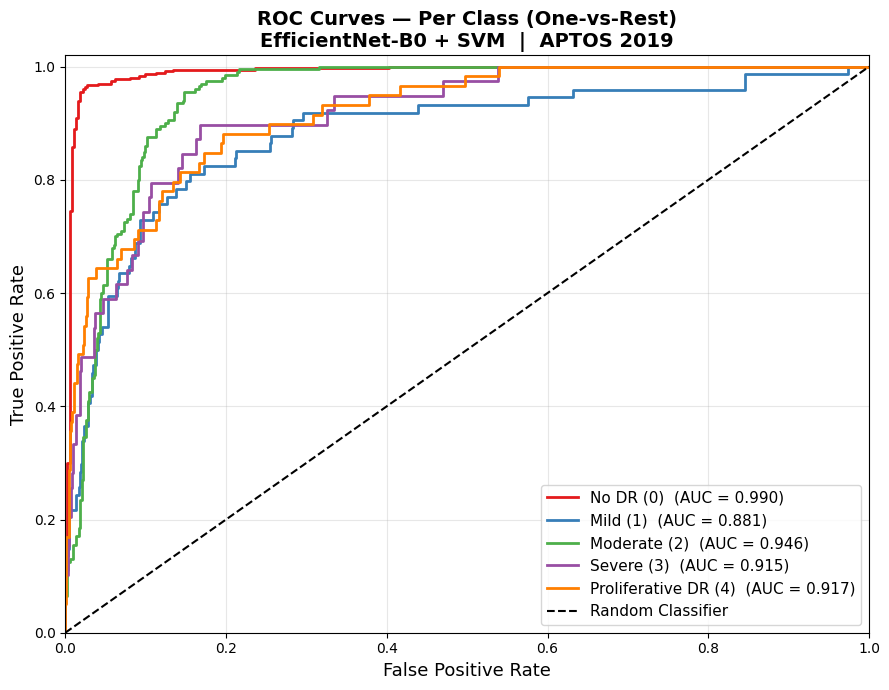

Saved: roc_per_class.png


In [14]:
COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

fig, ax = plt.subplots(figsize=(9, 7))

for i in range(NUM_CLASSES):
    ax.plot(
        fpr[i], tpr[i],
        color=COLORS[i], lw=2,
        label=f'{CLASS_NAMES[i]}  (AUC = {roc_auc[i]:.3f})'
    )

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title(
    'ROC Curves — Per Class (One-vs-Rest)\nEfficientNet-B0 + SVM  |  APTOS 2019',
    fontsize=14, fontweight='bold'
)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_per_class.png")

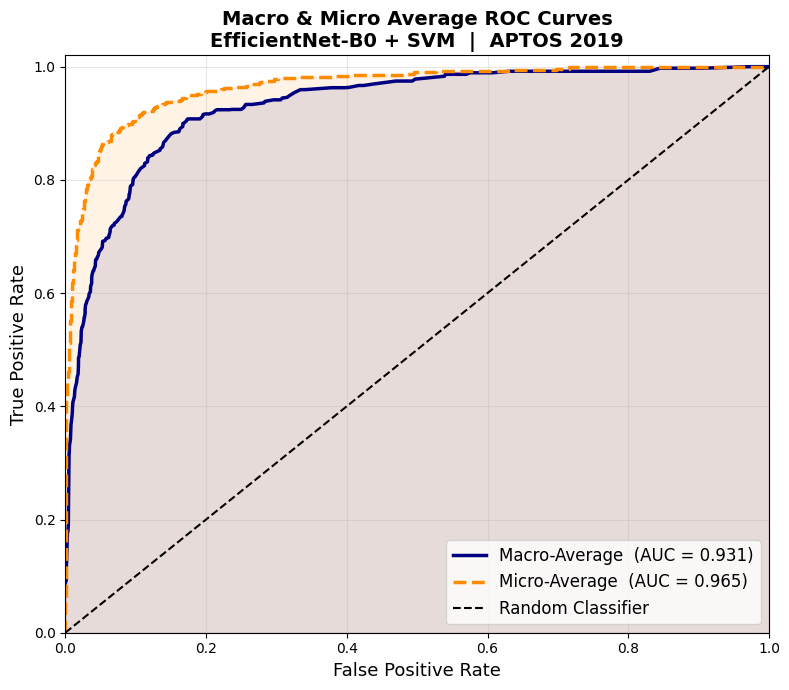

Saved: roc_average.png


In [15]:
fig, ax = plt.subplots(figsize=(8, 7))

ax.plot(
    fpr['macro'], tpr['macro'],
    color='navy', lw=2.5, linestyle='-',
    label=f'Macro-Average  (AUC = {roc_auc["macro"]:.3f})'
)
ax.fill_between(fpr['macro'], tpr['macro'], alpha=0.10, color='navy')

ax.plot(
    fpr['micro'], tpr['micro'],
    color='darkorange', lw=2.5, linestyle='--',
    label=f'Micro-Average  (AUC = {roc_auc["micro"]:.3f})'
)
ax.fill_between(fpr['micro'], tpr['micro'], alpha=0.10, color='darkorange')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title(
    'Macro & Micro Average ROC Curves\nEfficientNet-B0 + SVM  |  APTOS 2019',
    fontsize=14, fontweight='bold'
)
ax.legend(loc='lower right', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_average.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_average.png")

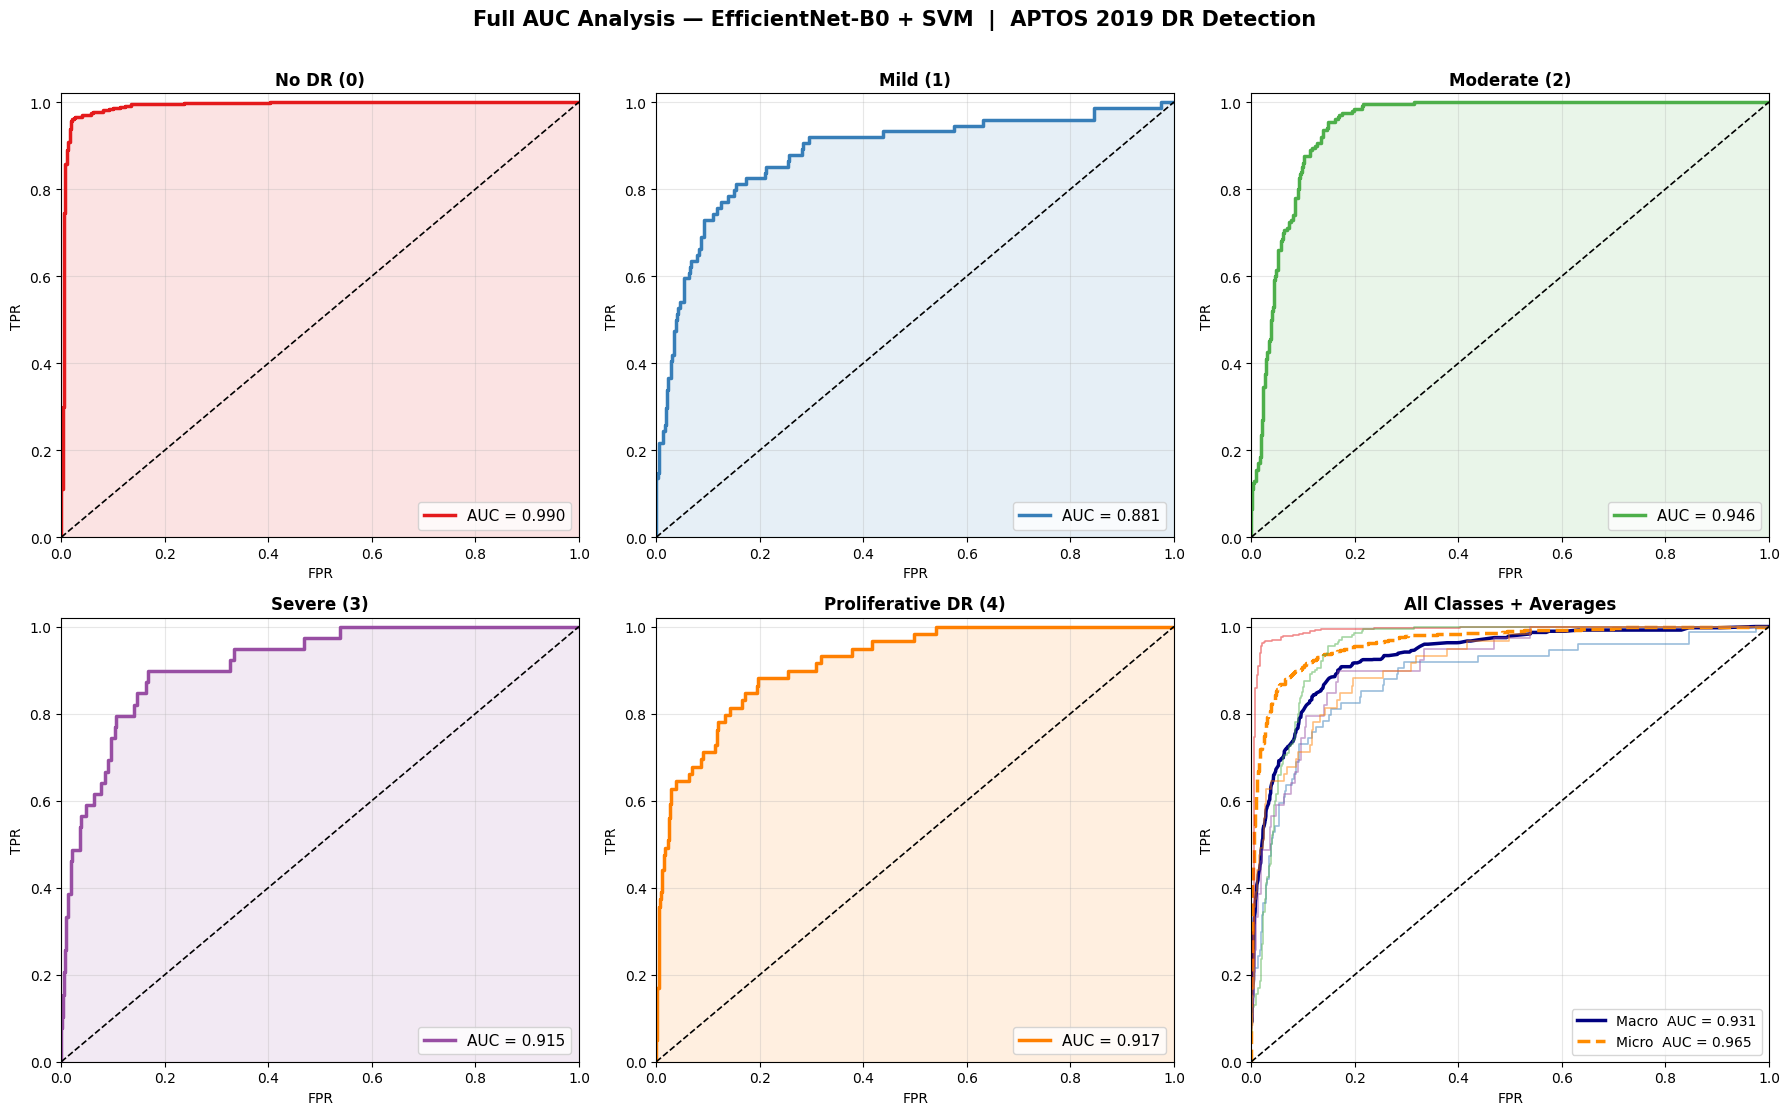

Saved: roc_full_analysis.png


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

# Individual class subplots
for i in range(NUM_CLASSES):
    ax = axes[i]
    ax.plot(fpr[i], tpr[i], color=COLORS[i], lw=2.5,
            label=f'AUC = {roc_auc[i]:.3f}')
    ax.fill_between(fpr[i], tpr[i], alpha=0.12, color=COLORS[i])
    ax.plot([0, 1], [0, 1], 'k--', lw=1.2)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_title(f'{CLASS_NAMES[i]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('FPR', fontsize=10)
    ax.set_ylabel('TPR', fontsize=10)
    ax.legend(loc='lower right', fontsize=11)
    ax.grid(True, alpha=0.3)

# Last subplot: all averages together
ax = axes[5]
ax.plot(fpr['macro'], tpr['macro'], color='navy', lw=2.5,
        label=f'Macro  AUC = {roc_auc["macro"]:.3f}')
ax.plot(fpr['micro'], tpr['micro'], color='darkorange', lw=2.5,
        linestyle='--', label=f'Micro  AUC = {roc_auc["micro"]:.3f}')
for i in range(NUM_CLASSES):
    ax.plot(fpr[i], tpr[i], color=COLORS[i], lw=1.2, alpha=0.5)
ax.plot([0, 1], [0, 1], 'k--', lw=1.2)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_title('All Classes + Averages', fontsize=12, fontweight='bold')
ax.set_xlabel('FPR', fontsize=10)
ax.set_ylabel('TPR', fontsize=10)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

fig.suptitle(
    'Full AUC Analysis — EfficientNet-B0 + SVM  |  APTOS 2019 DR Detection',
    fontsize=15, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('roc_full_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_full_analysis.png")

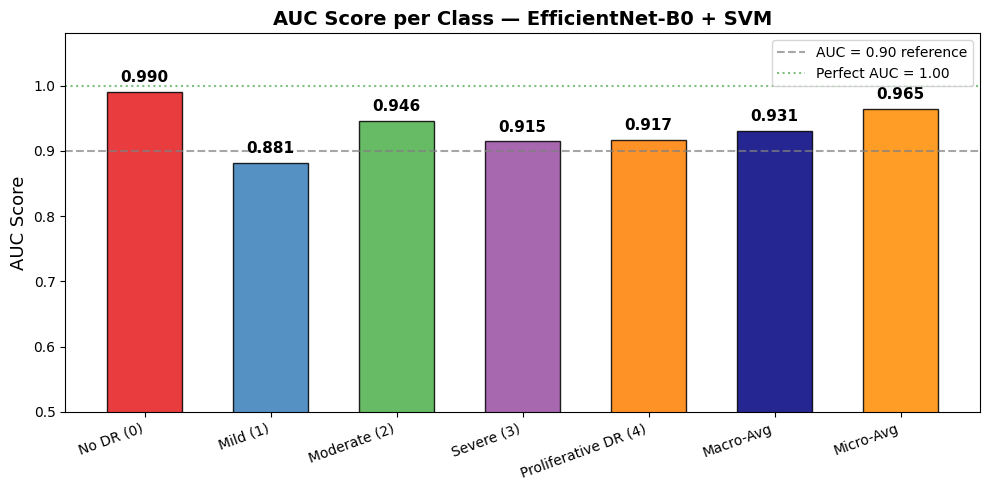

Saved: auc_bar_summary.png


In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

bar_labels = CLASS_NAMES + ['Macro-Avg', 'Micro-Avg']
bar_scores = ([roc_auc[i] for i in range(NUM_CLASSES)]
              + [roc_auc['macro'], roc_auc['micro']])
bar_colors = COLORS + ['navy', 'darkorange']

bars = ax.bar(bar_labels, bar_scores,
              color=bar_colors, edgecolor='black',
              width=0.6, alpha=0.85)

ax.set_ylim([0.5, 1.08])
ax.axhline(y=0.90, color='gray', linestyle='--',
           alpha=0.7, lw=1.5, label='AUC = 0.90 reference')
ax.axhline(y=1.00, color='green', linestyle=':',
           alpha=0.5, lw=1.5, label='Perfect AUC = 1.00')
ax.set_ylabel('AUC Score', fontsize=13)
ax.set_title(
    'AUC Score per Class — EfficientNet-B0 + SVM',
    fontsize=14, fontweight='bold'
)
ax.set_xticklabels(bar_labels, rotation=20, ha='right', fontsize=10)
ax.legend(fontsize=10)

for bar, score in zip(bars, bar_scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.010,
        f'{score:.3f}',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('auc_bar_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: auc_bar_summary.png")